In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
from pathlib import Path


pd.set_option("display.float_format", "{:.3f}".format)

In [73]:
def load_config(config_path):
    with open(config_path, "r") as f:
        config = yaml.safe_load(f)
    return config

In [74]:
base_path = Path.cwd().parent
config_path = base_path / "config" / "config.yaml"
cfg = load_config(config_path)
data_path = cfg["paths"]["raw_path"]

In [75]:
df = pd.read_csv(base_path / data_path)

In [76]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.647,-73.972,Private room,149,1,9,2018-10-19,0.210,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.754,-73.984,Entire home/apt,225,1,45,2019-05-21,0.380,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.809,-73.942,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.685,-73.960,Entire home/apt,89,1,270,2019-07-05,4.640,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.799,-73.944,Entire home/apt,80,10,9,2018-11-19,0.100,1,0


In [77]:
df.shape

(48895, 16)

In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [79]:
df.isnull().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [80]:
df.duplicated().sum()

np.int64(0)

In [81]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,48895.000,19017143.236,10983108.386,2539.000,9471945.000,19677284.000,29152178.500,36487245.000
host_id,48895.000,67620010.647,78610967.033,2438.000,7822033.000,30793816.000,107434423.000,274321313.000
latitude,48895.000,40.729,0.055,40.500,40.690,40.723,40.763,40.913
longitude,48895.000,-73.952,0.046,-74.244,-73.983,-73.956,-73.936,-73.713
price,48895.000,152.721,240.154,0.000,69.000,106.000,175.000,10000.000
minimum_nights,48895.000,7.030,20.511,1.000,1.000,3.000,5.000,1250.000
number_of_reviews,48895.000,23.274,44.551,0.000,1.000,5.000,24.000,629.000
reviews_per_month,38843.000,1.373,1.680,0.010,0.190,0.720,2.020,58.500
calculated_host_listings_count,48895.000,7.144,32.953,1.000,1.000,1.000,2.000,327.000
availability_365,48895.000,112.781,131.622,0.000,0.000,45.000,227.000,365.000


In [83]:
df = df[df["price"] < 1000]

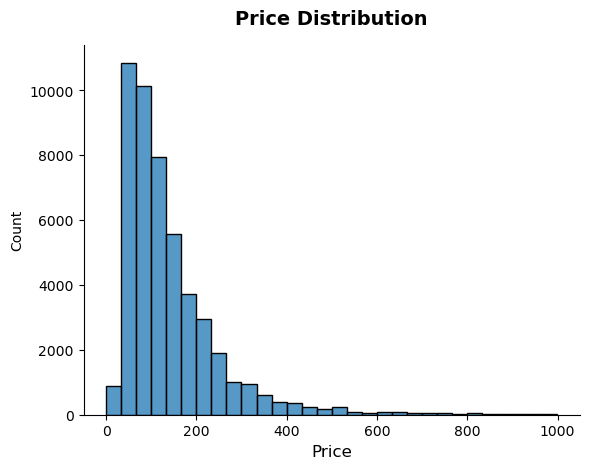

In [84]:
ax = sns.histplot(data=df, x="price", bins=30)
sns.despine(ax=ax)
plt.title("Price Distribution", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Price", fontsize=12)
plt.show()

In [85]:
df["room_type"].value_counts()

room_type
Entire home/apt    25166
Private room       22275
Shared room         1156
Name: count, dtype: int64

In [86]:
df["neighbourhood_group"].value_counts()

neighbourhood_group
Manhattan        21448
Brooklyn         20037
Queens            5653
Bronx             1089
Staten Island      370
Name: count, dtype: int64

C:\Users\selim\AppData\Local\Temp\ipykernel_12636\3915022154.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="neighbourhood_group", y="price", palette=palettes)


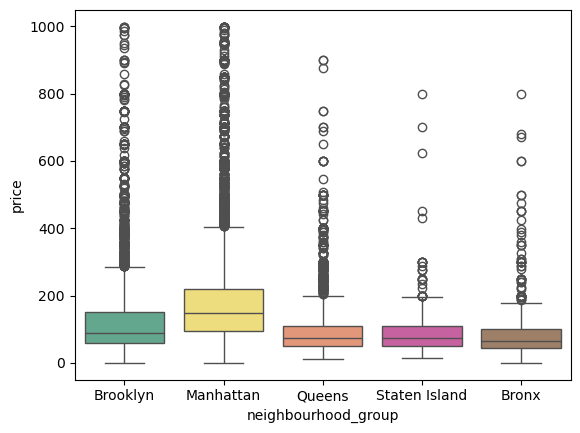

In [87]:
palettes = ["#59B292", "#FFEA6C", "#F48F68", "#D552A3", "#A77F60"]
plt.Figure(figsize=(12, 20))
sns.boxplot(data=df, x="neighbourhood_group", y="price", palette=palettes)
plt.show()

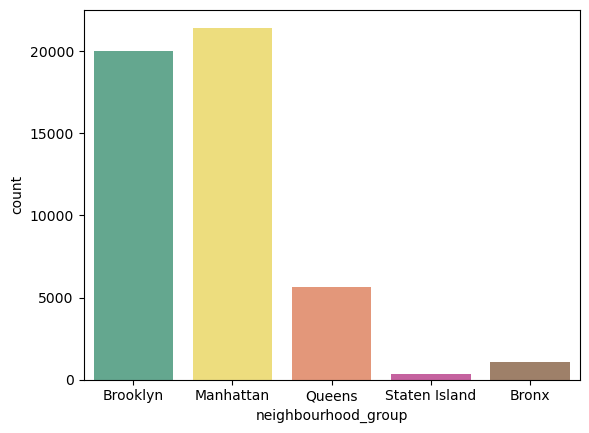

In [92]:
sns.countplot(data=df, x="neighbourhood_group", hue="neighbourhood_group", palette=palettes)
plt.show()

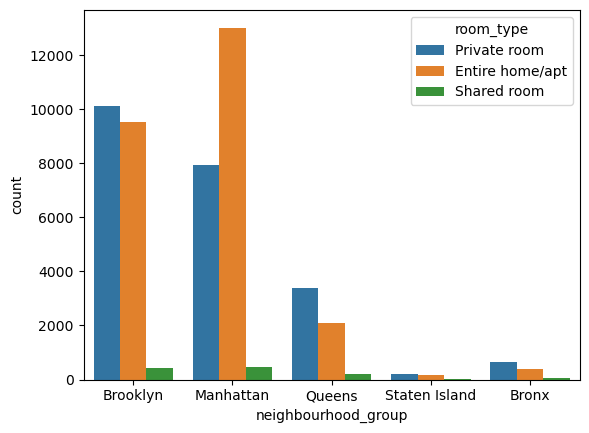

In [88]:
sns.countplot(data=df, x="neighbourhood_group", hue="room_type")
plt.show()

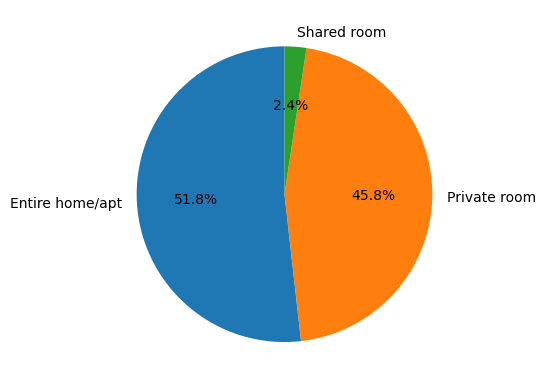

In [ ]:
room_type_counts = df["room_type"].value_counts()

fig, ax = plt.subplots()

ax.pie(
    room_type_counts,
    labels=room_type_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.show()

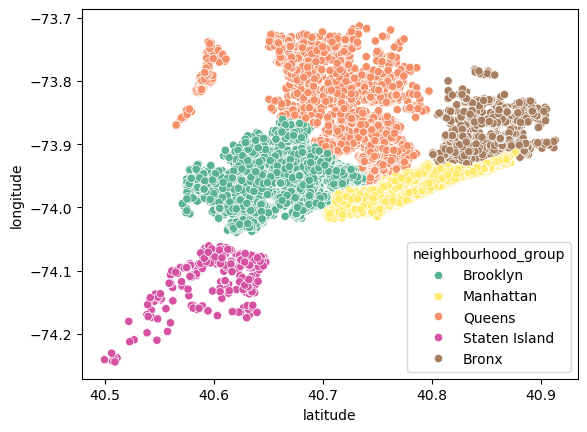

In [89]:
sns.scatterplot(data=df, x="latitude", y="longitude", hue="neighbourhood_group", palette=palettes)
plt.show()

In [90]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.647,-73.972,Private room,149,1,9,2018-10-19,0.210,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.754,-73.984,Entire home/apt,225,1,45,2019-05-21,0.380,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.809,-73.942,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.685,-73.960,Entire home/apt,89,1,270,2019-07-05,4.640,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.799,-73.944,Entire home/apt,80,10,9,2018-11-19,0.100,1,0
